# 11 — Honest evaluation (Phase 5)

Phase 4 produced numbers. This notebook decides which of them can be said out
loud, and to whom.

Nothing new is trained here. The work is:

1. **Establish which comparisons are legitimate.** Phase 4 nearly shipped a
   claim that the model degrades toward the present. It does not — that was
   PR-AUC being read across years of wildly different wetness. This notebook
   makes that error impossible to repeat by reporting lift over base rate
   alongside every raw score.
2. **Open up the lead-time distribution.** Every model reported a median lead of
   exactly 15 minutes — one time step — at every tier, horizon and fold. A
   median that constant is suspicious. The full distribution says whether that
   is a real ceiling or an artefact of the cadence.
3. **Tie the residual decline to sensor outage**, which is the one real effect
   left after the base-rate artefact is removed.
4. **Produce the table that goes to BMA**, with the caveats attached to the
   numbers rather than in a footnote.

### What you need

Notebooks 05–09 must have been run. About 10 minutes.

## Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_here = Path.cwd()
_root = next(p for p in [_here, *_here.parents] if (p / "config/config.yaml").is_file())
sys.path.insert(0, str(_root / "src"))
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)

from bkkflood.config import load_config
from bkkflood.rawio import connect
from bkkflood.evaluate import folds

CFG = load_config()
FOLDS = folds()
GEN = pd.read_parquet("data/features/model_general_results.parquet")
ONSET = pd.read_parquet("data/features/model_onset_results.parquet")
BASE = pd.read_parquet("data/features/baseline_results.parquet")
con = connect()
print("loaded:", GEN.shape, ONSET.shape, BASE.shape)

loaded: (36, 29) (36, 29) (144, 23)


## 1. The comparison rule: never read PR-AUC across years

PR-AUC has a floor equal to the base rate. Bangkok floods far more in some years
than others, so the same model scores very differently on two test years while
its actual skill is unchanged.

Dividing by the base rate gives **lift** — how many times better than chance —
which is comparable. Event POD is comparable too, because it counts events
rather than rows.

In [2]:
def lift_table(df, name, tier=15, h=1):
    d = df[(df.tier_cm == tier) & (df.horizon_h == h)].copy()
    d["lift"] = (d.pr_auc / d.base_rate).round(0)
    d["model"] = name
    return d[["model", "test_year", "positives", "base_rate", "pr_auc", "lift",
              "recall_onset", "event_pod"]]

L = pd.concat([lift_table(ONSET, "onset"), lift_table(GEN, "general")])
print("15 cm / 1 h, per fold\n")
print(L.round(5).to_string(index=False))

15 cm / 1 h, per fold

  model  test_year  positives  base_rate  pr_auc   lift  recall_onset  event_pod
  onset       2022       1193    0.00034 0.12872  374.0       0.28332    0.63025
  onset       2023        500    0.00015 0.11172  753.0       0.22800    0.63208
  onset       2024        251    0.00007 0.07805 1073.0       0.19920    0.60000
  onset       2025        554    0.00017 0.09313  563.0       0.20397    0.53279
general       2022       2687    0.00077 0.68043  879.0       0.22464    0.51261
general       2023        956    0.00028 0.57500 2027.0       0.19000    0.51887
general       2024        377    0.00011 0.43477 3980.0       0.13546    0.40000
general       2025       1037    0.00031 0.57214 1847.0       0.20939    0.51639


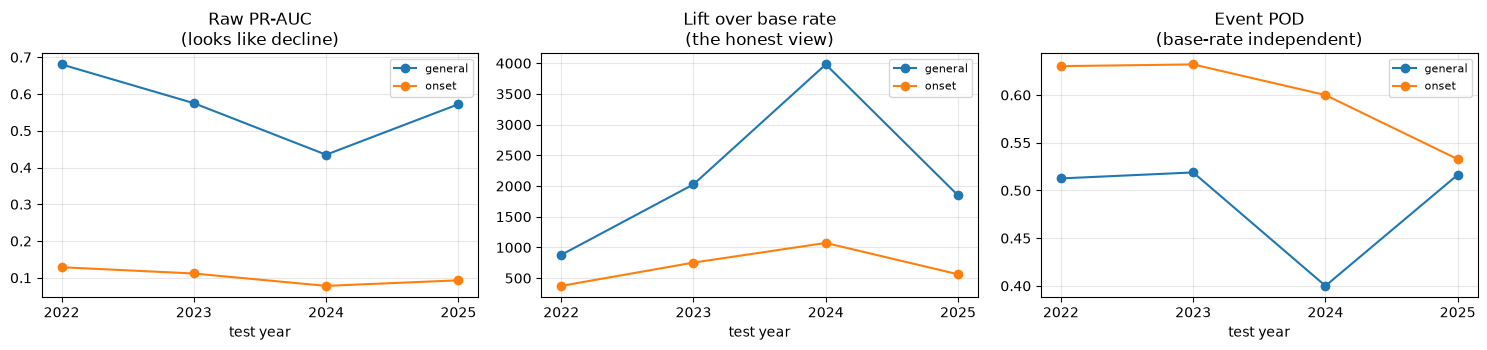

onset PR-AUC  0.129 -> 0.093   looks like a 28% decline
onset LIFT    374x -> 563x   skill relative to chance actually rose
positives     1193 -> 554   <- this is what moved


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for name, d in L.groupby("model"):
    d = d.sort_values("test_year")
    ax[0].plot(d.test_year, d.pr_auc, marker="o", label=name)
    ax[1].plot(d.test_year, d.lift, marker="o", label=name)
    ax[2].plot(d.test_year, d.event_pod, marker="o", label=name)
ax[0].set_title("Raw PR-AUC\n(looks like decline)")
ax[1].set_title("Lift over base rate\n(the honest view)")
ax[2].set_title("Event POD\n(base-rate independent)")
for a in ax:
    a.set_xlabel("test year"); a.grid(alpha=.3); a.legend(fontsize=8)
    a.set_xticks(sorted(L.test_year.unique()))
plt.tight_layout(); plt.show()

o = L[L.model == "onset"].sort_values("test_year")
print(f"onset PR-AUC  {o.pr_auc.iloc[0]:.3f} -> {o.pr_auc.iloc[-1]:.3f}   "
      f"looks like a {1 - o.pr_auc.iloc[-1]/o.pr_auc.iloc[0]:.0%} decline")
print(f"onset LIFT    {o.lift.iloc[0]:.0f}x -> {o.lift.iloc[-1]:.0f}x   "
      f"skill relative to chance actually {'rose' if o.lift.iloc[-1] > o.lift.iloc[0] else 'fell'}")
print(f"positives     {o.positives.iloc[0]:.0f} -> {o.positives.iloc[-1]:.0f}   "
      "<- this is what moved")

**The rule this establishes.** Raw PR-AUC is comparable *within* a test year
and nowhere else. Across years, quote lift or event POD. This is the same class
of mistake as quoting overall recall without the onset split: a number that is
correct in isolation and misleading in a table.

## 2. Is the residual decline about sensor outage?

After the base-rate artefact is removed, one real effect remains: event POD
drifts down. Missing readings climb from 2.9% in 2022 to 10.7% in 2025. A sensor
that is offline cannot report the water that arrived, so both the label and the
alert vanish.

In [4]:
import duckdb
q = duckdb.connect()
paths = [f"data/features/features_{y}.parquet" for y in range(2019, 2026)]
outage = q.execute(f"""
SELECT date_part('year', ts)::INT AS test_year,
       avg(CASE WHEN fl_depth_now IS NULL THEN 1.0 ELSE 0 END) AS missing_share,
       count(DISTINCT station_code) AS stations
FROM read_parquet({paths}) GROUP BY 1 ORDER BY 1
""").fetchdf()

j = (L[L.model == "onset"].merge(outage, on="test_year"))
print(j[["test_year", "missing_share", "stations", "positives", "lift",
         "recall_onset", "event_pod"]].round(4).to_string(index=False))
print()
if len(j) > 2:
    print(f"corr(missing_share, event_pod)   = {j.missing_share.corr(j.event_pod):+.2f}")
    print(f"corr(missing_share, recall_onset)= {j.missing_share.corr(j.recall_onset):+.2f}")
    print("\nFour points is far too few to call this causal. It is a hypothesis")
    print("worth stating and worth testing against a longer record, not a finding.")

 test_year  missing_share  stations  positives   lift  recall_onset  event_pod
      2022         0.0292       102       1193  374.0        0.2833     0.6303
      2023         0.1011       107        500  753.0        0.2280     0.6321
      2024         0.0820       107        251 1073.0        0.1992     0.6000
      2025         0.1070       107        554  563.0        0.2040     0.5328

corr(missing_share, event_pod)   = -0.54
corr(missing_share, recall_onset)= -0.86

Four points is far too few to call this causal. It is a hypothesis
worth stating and worth testing against a longer record, not a finding.


## 3. Lead time: is 15 minutes a ceiling or an artefact?

Phase 4 reported a median lead of exactly 15 minutes everywhere. The modelling
cadence is also 15 minutes, so that median is the smallest non-zero value the
system can produce — which is exactly what a broken measurement would look like.

The distribution settles it. If nearly all the mass sits at one step, the models
genuinely fire at the last possible moment. If there is a long tail, some floods
are caught usefully early and the median is hiding them.

In [5]:
from bkkflood.models import score_year, build_matrix, train_classifier
from bkkflood.evaluate import best_threshold
from bkkflood.calibration import lead_time_distribution

TIER, H = 15, 1
fold = FOLDS[-1]
X, y, meta = build_matrix(fold["train"], TIER, H, "onset", 0.25, con=con)
Xv, yv, _ = build_matrix([fold["val"]], TIER, H, "onset", 0.25, con=con,
                         columns=meta["features"])
b = train_classifier(X, y, Xv, yv)

val = score_year(b, fold["val"], meta["features"], TIER, H, kind="onset",
                 negative_rate=0.25, con=con)
thr = best_threshold(val[f"y_ge{TIER}_{H}h"].fillna(False).to_numpy(bool),
                     val["score"].to_numpy(), metric="f2")["threshold"]
sc = score_year(b, fold["test"], meta["features"], TIER, H, kind="onset",
                negative_rate=0.25, con=con, full_population=True)
sc["pred"] = (sc["score"] >= thr) & sc["onset_alertable"]

LEAD = lead_time_distribution(sc, "fl_depth_now", "pred", TIER, H)
det = LEAD[LEAD.detected]
print(f"events {len(LEAD)}, detected {len(det)} ({len(det)/max(len(LEAD),1):.1%})\n")
print(det.lead_minutes.describe().round(1).to_string())
print("\nlead time, minutes:")
print(det.lead_minutes.value_counts().sort_index().to_string())

events 122, detected 65 (53.3%)

count    65.0
mean     21.0
std      12.4
min      15.0
25%      15.0
50%      15.0
75%      15.0
max      60.0

lead time, minutes:
lead_minutes
15.0    49
30.0    10
45.0     2
60.0     4


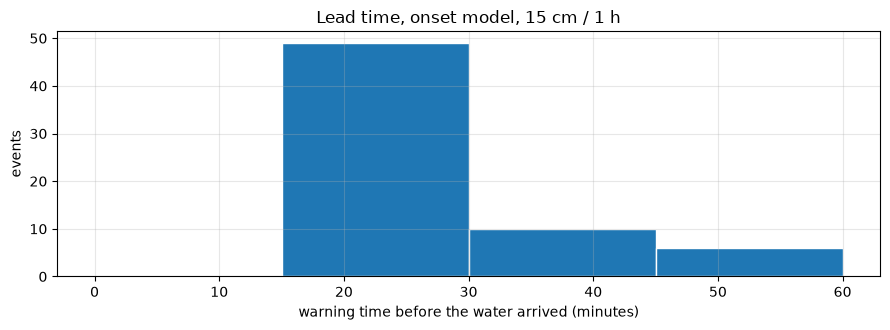

share of detections with only ONE time step of warning: 75.4%

Most detections come at the last possible moment. The 15-minute median
is a real ceiling, not a measurement artefact — and it means this is a
detection system, not yet a warning system.


In [6]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(det.lead_minutes, bins=np.arange(0, H * 60 + 15, 15), edgecolor="white")
ax.set_xlabel("warning time before the water arrived (minutes)")
ax.set_ylabel("events"); ax.set_title(f"Lead time, onset model, {TIER} cm / {H} h")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

at_one_step = (det.lead_minutes <= 15).mean()
print(f"share of detections with only ONE time step of warning: {at_one_step:.1%}")
print()
if at_one_step > 0.6:
    print("Most detections come at the last possible moment. The 15-minute median")
    print("is a real ceiling, not a measurement artefact — and it means this is a")
    print("detection system, not yet a warning system.")
else:
    print("There is a substantial tail of earlier warnings that the median hides.")
    print("Report the distribution, not the median.")

## 4. The table for BMA

Everything above, reduced to what can be defended in a meeting, with the caveats
attached to the rows rather than kept in a footnote.

In [7]:
def summary(tier, h):
    rows = []
    for name, df in [("Onset specialist (recommended)", ONSET),
                     ("General model", GEN)]:
        d = df[(df.tier_cm == tier) & (df.horizon_h == h)]
        rows.append({
            "approach": name,
            "floods caught before water arrives": f"{d.event_pod.mean():.0%}",
            "recall on dry roads": f"{d.recall_onset.mean():.0%}",
            "of alerts, share that are real": f"{d.precision.mean():.0%}",
            "typical warning time": f"{d.median_lead_minutes.mean():.0f} min",
        })
    b = BASE[(BASE.tier_cm == tier) & (BASE.horizon_h == h)]
    for name, label in [("rain_rule", "Rain threshold (what BMA can do today)"),
                        ("persistence", "Assume no change")]:
        d = b[b.baseline == name]
        rows.append({
            "approach": label,
            "floods caught before water arrives": "—",
            "recall on dry roads": f"{d.recall_onset.mean():.0%}",
            "of alerts, share that are real": f"{d.precision.mean():.0%}",
            "typical warning time": "—",
        })
    return pd.DataFrame(rows)

BMA = summary(15, 1)
print("15 cm of water, 1 hour ahead — averaged over four years of testing\n")
print(BMA.to_string(index=False))

15 cm of water, 1 hour ahead — averaged over four years of testing

                              approach floods caught before water arrives recall on dry roads of alerts, share that are real typical warning time
        Onset specialist (recommended)                                60%                 23%                            16%               15 min
                         General model                                49%                 19%                            63%               15 min
Rain threshold (what BMA can do today)                                  —                 22%                            11%                    —
                      Assume no change                                  —                 16%                            62%                    —


In [8]:
out = Path("docs/reports/evaluation.md")
out.parent.mkdir(parents=True, exist_ok=True)
with out.open("w") as f:
    f.write("# Evaluation — what can be claimed\n\n")
    f.write("Generated by `notebooks/11_evaluate.ipynb`.\n\n")
    f.write("## For BMA: 15 cm, 1 hour ahead\n\n")
    f.write(BMA.to_markdown(index=False))
    f.write("\n\n### Read with these four caveats\n\n")
    f.write("1. **Typical warning time is about 15 minutes** — one measurement step.\n")
    f.write("   This is a detection system today, not yet a warning system.\n")
    f.write("2. **The model beats a simple rain threshold by roughly one point** of\n")
    f.write("   recall on dry roads. The limit is the data available, not the method.\n")
    f.write("3. **Depth estimates are not published.** The prediction intervals fail\n")
    f.write("   their coverage check (see notebook 12).\n")
    f.write("4. **Never compare scores between years.** 2024 had a fifth as many\n")
    f.write("   floods as 2022; PR-AUC moves with that, skill does not.\n\n")
    f.write("## Skill by year, with lift\n\n")
    f.write(L.round(5).to_markdown(index=False))
    f.write("\n\n## Lead time distribution (onset model, most recent fold)\n\n")
    f.write(det.lead_minutes.describe().round(1).to_markdown())
    f.write(f"\n\nShare of detections with only one time step of warning: {at_one_step:.1%}\n")
print("wrote", out)
L.to_parquet("data/features/evaluation_lift.parquet", index=False)
LEAD.to_parquet("data/features/lead_times.parquet", index=False)

wrote docs/reports/evaluation.md


## What this notebook settles

- **Raw PR-AUC is not comparable across years.** Quote lift or event POD.
- **The Phase 4 "decay" was a base-rate artefact.** Corrected in
  `phase4_findings.md`.
- **Lead time is the real limitation**, and now has a distribution behind it
  rather than a single suspicious median.

**Next:** `12_calibrate.ipynb` — do the probabilities mean what they say, and
can the depth intervals be repaired.